In [ ]:
#imports 
from SPARQLWrapper import SPARQLWrapper
from SPARQLWrapper import JSON, CSV
import matplotlib.pyplot as plt
from SPARQLWrapper import TURTLE
from rdflib import Graph
from rdflib.plugins.sparql.results.jsonresults import JSONResult
from utils import show_graph
from utils import save_graph_html
import os
import importlib
import utils 
importlib.reload(utils)
import time
import networkx as nx
import csv
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import io
import seaborn as sns

In [ ]:
#set it uppppp
#sparql endpoint
endpoint = SPARQLWrapper(" ")
endpoint.setReturnFormat(JSON)
output_dir = "./evolution_reseaux"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

#initialisation de variables
periode = 5

#requete sparql
query_date_intervalle = """
                PREFIX rico: <https://www.ica.org/standards/RiC/ontology#>
                SELECT  ?s ?nomagent ?debut ?fin
                where{
                ?s a rico:Record;
                    rico:hasCreationDate ?date.
                    ?date rico:beginningDate ?debut;
                        rico:endDate ?fin.
                ?rel rico:relationHasSource ?s .  
                ?rel rico:relationHasTarget ?agent .
                ?agent rico:name ?nomagent
                }
                ORDER BY DESC (?fin)

                    """

In [27]:
#On ajoute les reponses de la requete a un df en passant par un format csv
endpoint.setQuery(query_date_intervalle)
endpoint.setReturnFormat(CSV)
resultats_csv = endpoint.queryAndConvert()
#bytesIO permet de lire les bytes comme du csv
df = pd.read_csv(io.BytesIO(resultats_csv))


In [28]:
df.head()

,s,nomagent,debut,fin
0,http://rdf.geohistoricaldata.org/id/museeCarna...,Anonyme,1882,2088
1,http://rdf.geohistoricaldata.org/id/museeCarna...,Imprimerie Charles Lévy (Paris),1882,2088
2,http://rdf.geohistoricaldata.org/id/museeCarna...,FOLIES-BERGERE,1882,2088
3,http://rdf.geohistoricaldata.org/id/museeCarna...,FOLIES BERGERE,1882,2088
4,http://rdf.geohistoricaldata.org/id/museeCarna...,Folies-Bergère,1882,2088


In [29]:
#fonction de nettoyage des date, on les met en fprmat annee
def clean_date_to_year(value):
        # On convertit en string pour manipuler uniformément
        val_str = str(value).strip()
        
        if not val_str or val_str.lower() == 'nan':
            return None # Sera géré par safe_int plus tard (ex: 1800)

        # Cas 1 : C'est déjà une année seule (4 chiffres exactement)
        if len(val_str) == 4 and val_str.isdigit():
            return int(val_str)
        
        # Cas 2 : C'est une date longue (ex: 1848-06-28)
        try:
            # pd.to_datetime est intelligent et extraira l'année
            return pd.to_datetime(val_str, errors='coerce').year
        except:
            return None

In [30]:
 # Application du nettoyage
df['debut'] = df['debut'].apply(clean_date_to_year)
df['fin'] = df['fin'].apply(clean_date_to_year)

In [31]:
#Calcul intervalle et moyenne
    #mais d'abord conversion
df['debut'] = pd.to_numeric(df['debut'])
df['fin'] = pd.to_numeric(df['fin'])

df['intervalle'] = df['fin'] - df['debut']
df['moy'] = (df['fin'] + df['debut'])/2

In [32]:
df.head()

,s,nomagent,debut,fin,intervalle,moy
0,http://rdf.geohistoricaldata.org/id/museeCarna...,Anonyme,1882,2088,206,1985.0
1,http://rdf.geohistoricaldata.org/id/museeCarna...,Imprimerie Charles Lévy (Paris),1882,2088,206,1985.0
2,http://rdf.geohistoricaldata.org/id/museeCarna...,FOLIES-BERGERE,1882,2088,206,1985.0
3,http://rdf.geohistoricaldata.org/id/museeCarna...,FOLIES BERGERE,1882,2088,206,1985.0
4,http://rdf.geohistoricaldata.org/id/museeCarna...,Folies-Bergère,1882,2088,206,1985.0


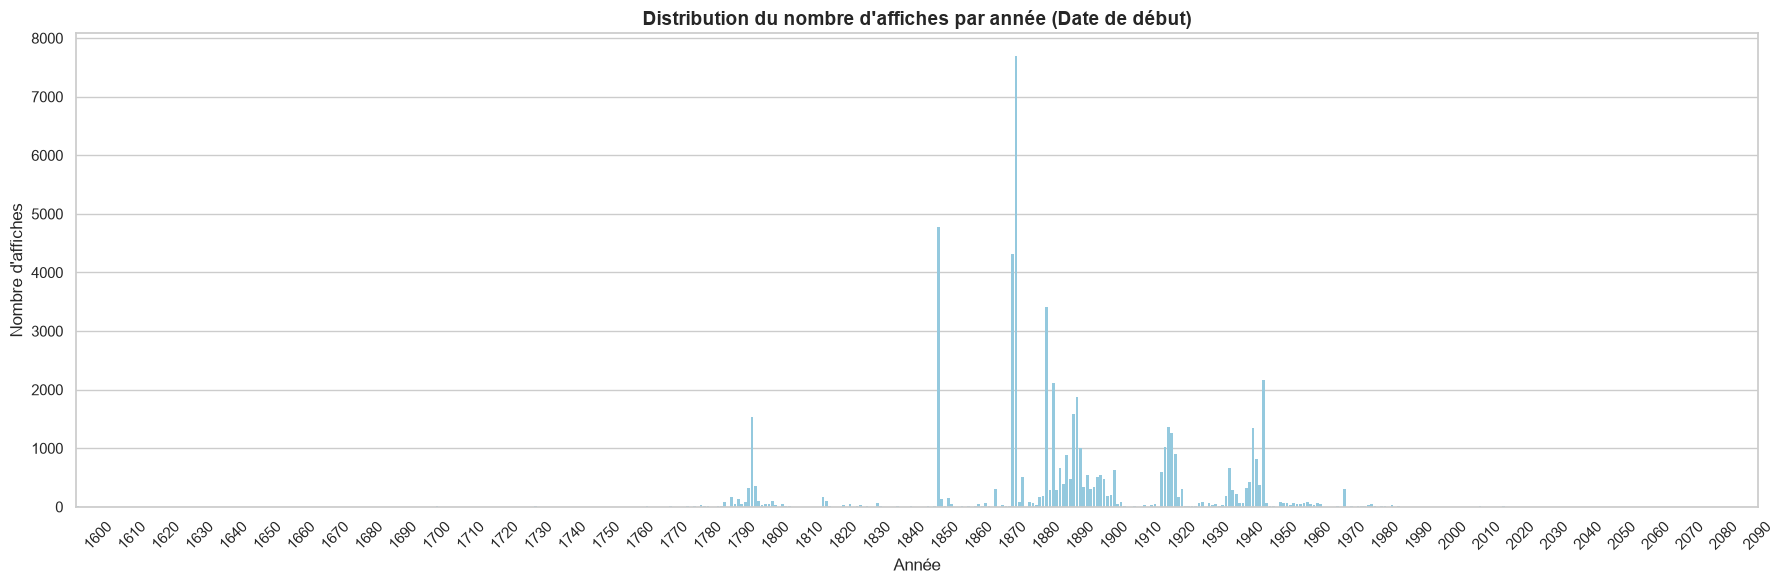

In [ ]:
# Configurer le style du graphique
plt.figure(figsize=(18, 6))
sns.set_theme(style="whitegrid")

# 1. Pré-calcul des fréquences par année sur toute la plage
annee_min = int(df['debut'].min())
annee_max = int(df['fin'].max())
toutes_les_annees = range(annee_min, annee_max + 1)

# Compter le nombre d'affiches par année de début (remplit à 0 si une année n'a aucune affiche)
count_debut = df['debut'].value_counts().reindex(toutes_les_annees, fill_value=0)

# Créer le DataFrame pour le barplot
df_debut = pd.DataFrame({
    'Annee': toutes_les_annees,
    'Nombre_affiches': count_debut.values
})

# 2. Créer le barplot (une barre par année)
sns.barplot(data=df_debut, x='Annee', y='Nombre_affiches', color='skyblue', edgecolor='none')

# 3. Ajustement dynamique des étiquettes de l'axe X (identique au premier graphique)
pas_affichage = 10
plt.xticks(
    ticks=range(6, 506, pas_affichage), 
    labels=range(1600, 2100, pas_affichage), 
    rotation=45
)

# Personnalisation des axes et titres
plt.title("Distribution du nombre d'affiches par année (Date de début)", fontsize=14, fontweight='bold')
plt.xlabel("Année", fontsize=12)
plt.ylabel("Nombre d'affiches", fontsize=12)

# Afficher le graphique
plt.tight_layout()
plt.savefig("", dpi=600)
plt.show()
plt.close()

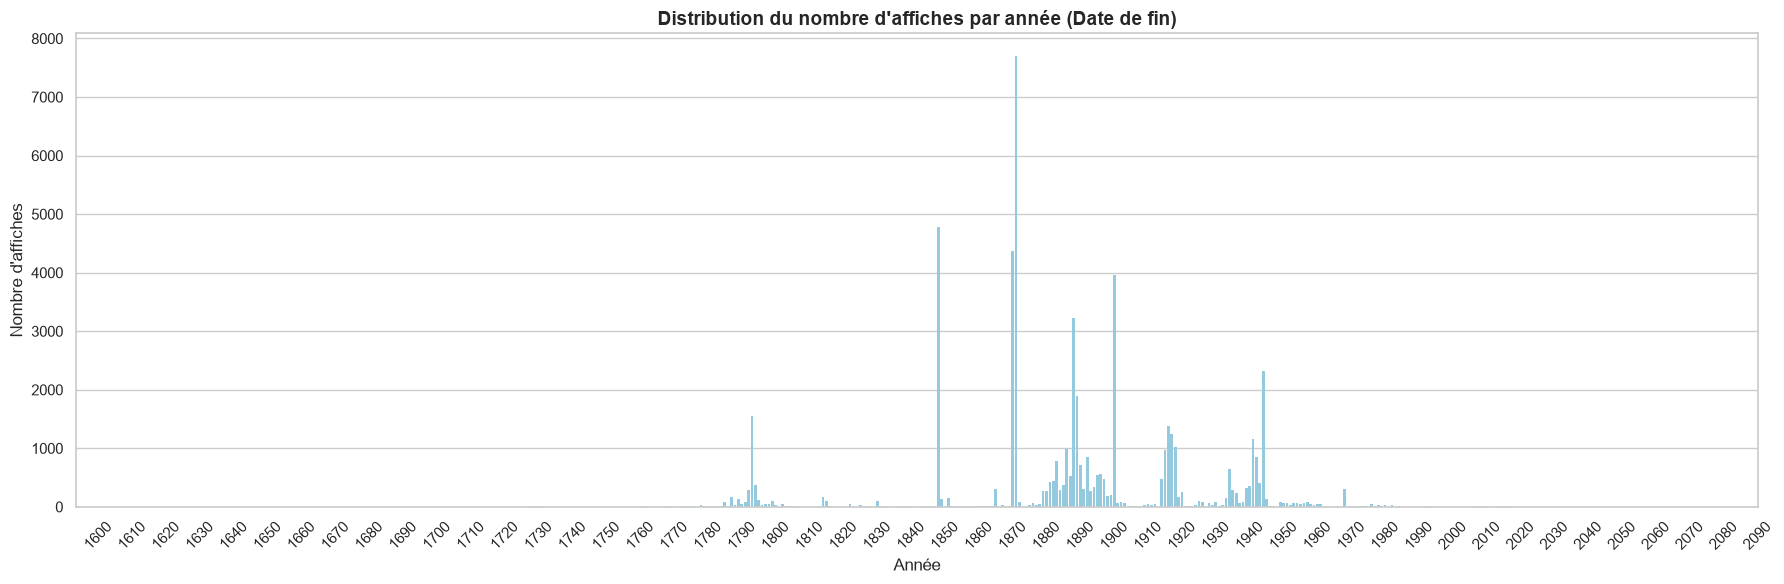

In [ ]:
# Configurer le style du graphique
plt.figure(figsize=(18, 6))
sns.set_theme(style="whitegrid")

# 1. Pré-calcul des fréquences par année de fin sur toute la plage
annee_min = int(df['debut'].min())
annee_max = int(df['fin'].max())
toutes_les_annees = range(annee_min, annee_max + 1)

# Compter le nombre d'affiches par année de fin (remplit à 0 si une année n'a aucune affiche)
count_fin = df['fin'].value_counts().reindex(toutes_les_annees, fill_value=0)

# Créer le DataFrame pour le barplot
df_fin = pd.DataFrame({
    'Annee': toutes_les_annees,
    'Nombre_affiches': count_fin.values
})

# 2. Créer le barplot
sns.barplot(data=df_fin, x='Annee', y='Nombre_affiches', color='skyblue', edgecolor='none')

# 3. Ajustement dynamique des étiquettes de l'axe X
pas_affichage = 10
plt.xticks(
    ticks=range(6, 506, pas_affichage), 
    labels=range(1600, 2100, pas_affichage), 
    rotation=45
)

# Personnalisation des axes et titres
plt.title("Distribution du nombre d'affiches par année (Date de fin)", fontsize=14, fontweight='bold')
plt.xlabel("Année", fontsize=12)
plt.ylabel("Nombre d'affiches", fontsize=12)

# Afficher le graphique
plt.tight_layout()
plt.savefig(" ", dpi=600)
plt.show()
plt.close()

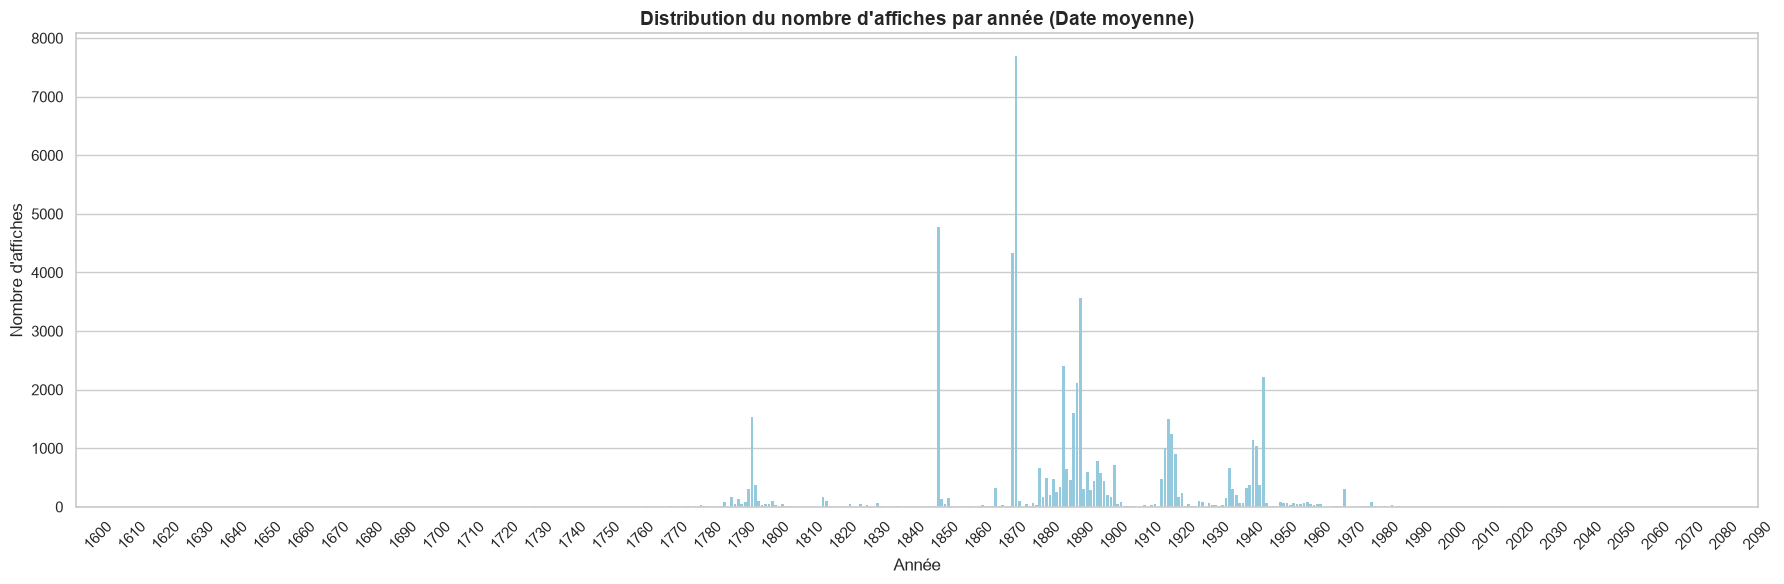

In [ ]:
# Configurer le style du graphique
plt.figure(figsize=(18, 6))
sns.set_theme(style="whitegrid")

# 1. Pré-calcul des fréquences par année moyenne sur toute la plage
annee_min = int(df['debut'].min())
annee_max = int(df['fin'].max())
toutes_les_annees = range(annee_min, annee_max + 1)

# Arrondir les valeurs de 'moy' en entiers si ce n'est pas déjà fait, puis compter
count_moy = df['moy'].round().value_counts().reindex(toutes_les_annees, fill_value=0)

# Créer le DataFrame pour le barplot
df_moy = pd.DataFrame({
    'Annee': toutes_les_annees,
    'Nombre_affiches': count_moy.values
})

# 2. Créer le barplot
sns.barplot(data=df_moy, x='Annee', y='Nombre_affiches', color='skyblue', edgecolor='none')

# 3. Ajustement dynamique des étiquettes de l'axe X
pas_affichage = 10
plt.xticks(
    ticks=range(6, 506, pas_affichage), 
    labels=range(1600, 2100, pas_affichage), 
    rotation=45
)

# Personnalisation des axes et titres
plt.title("Distribution du nombre d'affiches par année (Date moyenne)", fontsize=14, fontweight='bold')
plt.xlabel("Année", fontsize=12)
plt.ylabel("Nombre d'affiches", fontsize=12)

# Afficher le graphique
plt.tight_layout()
plt.savefig(" ", dpi=600)
plt.show()
plt.close()

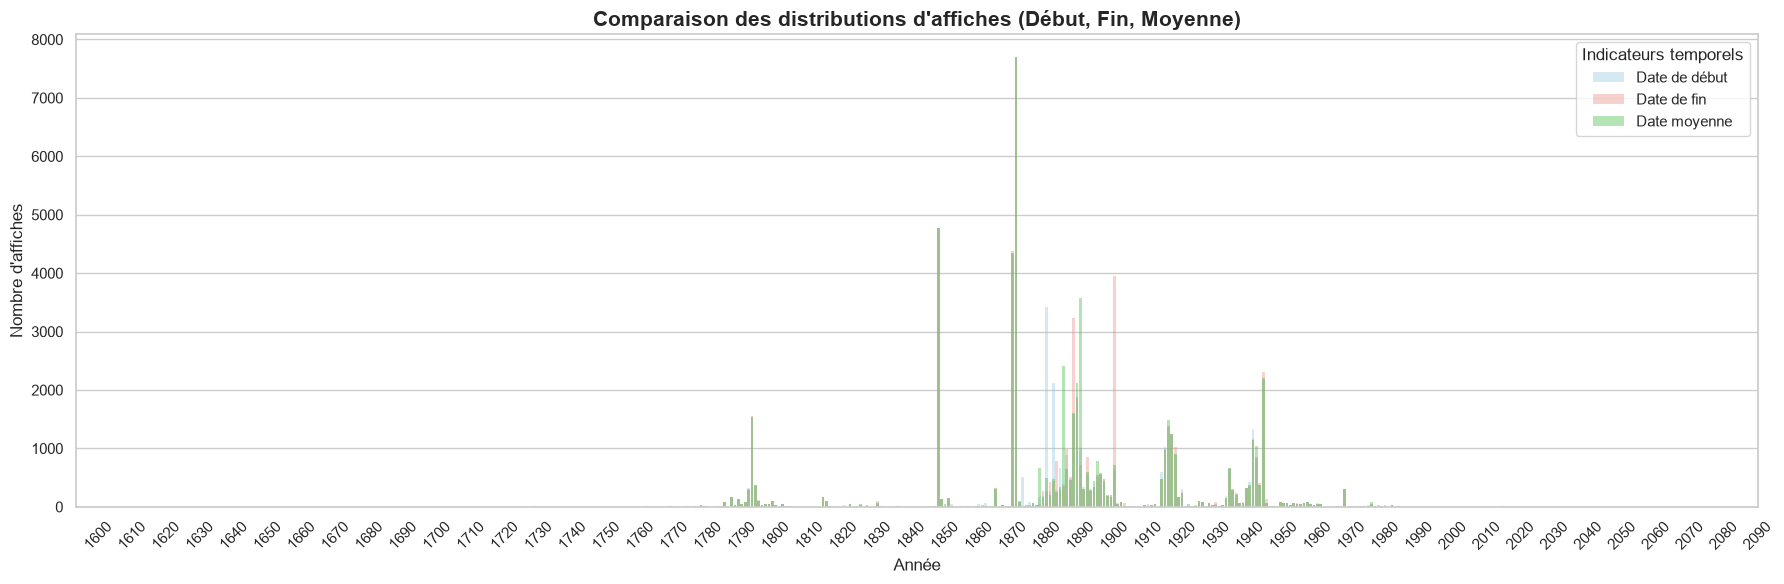

In [ ]:
# 1. Configuration du style et de la taille de la figure
plt.figure(figsize=(18, 6))
sns.set_theme(style="whitegrid")

# 2. Pré-calcul des fréquences par année sur toute la plage
annee_min = int(df['debut'].min())
annee_max = int(df['fin'].max())
toutes_les_annees = range(annee_min, annee_max + 1)

# Compter le nombre d'affiches pour chaque indicateur
count_debut = df['debut'].value_counts().reindex(toutes_les_annees, fill_value=0)
count_fin   = df['fin'].value_counts().reindex(toutes_les_annees, fill_value=0)
count_moy   = df['moy'].round().value_counts().reindex(toutes_les_annees, fill_value=0)

# Création du DataFrame structuré pour le barplot
df_counts = pd.DataFrame({
    'Annee': toutes_les_annees,
    'Debut': count_debut.values,
    'Fin': count_fin.values,
    'Moyenne': count_moy.values
})

# 3. Superposition des 3 séries avec sns.barplot
sns.barplot(data=df_counts, x='Annee', y='Debut', color='skyblue', label='Date de début', alpha=0.4, edgecolor='none')
sns.barplot(data=df_counts, x='Annee', y='Fin', color='salmon', label='Date de fin', alpha=0.4, edgecolor='none')
sns.barplot(data=df_counts, x='Annee', y='Moyenne', color='limegreen', label='Date moyenne', alpha=0.4, edgecolor='none')

# 4. Ajustement identique de l'axe X
pas_affichage = 10
plt.xticks(
    ticks=range(6, 506, pas_affichage), 
    labels=range(1600, 2100, pas_affichage), 
    rotation=45
)

# 5. Personnalisation des axes, du titre et de la légende
plt.title("Comparaison des distributions d'affiches (Début, Fin, Moyenne)", fontsize=15, fontweight='bold')
plt.xlabel("Année", fontsize=12)
plt.ylabel("Nombre d'affiches", fontsize=12)

# Affichage de la légende
plt.legend(title="Indicateurs temporels", fontsize=11, title_fontsize=12)

# 6. Affichage du graphique
plt.tight_layout()
plt.savefig(" ", dpi=600)
plt.show()
plt.close()

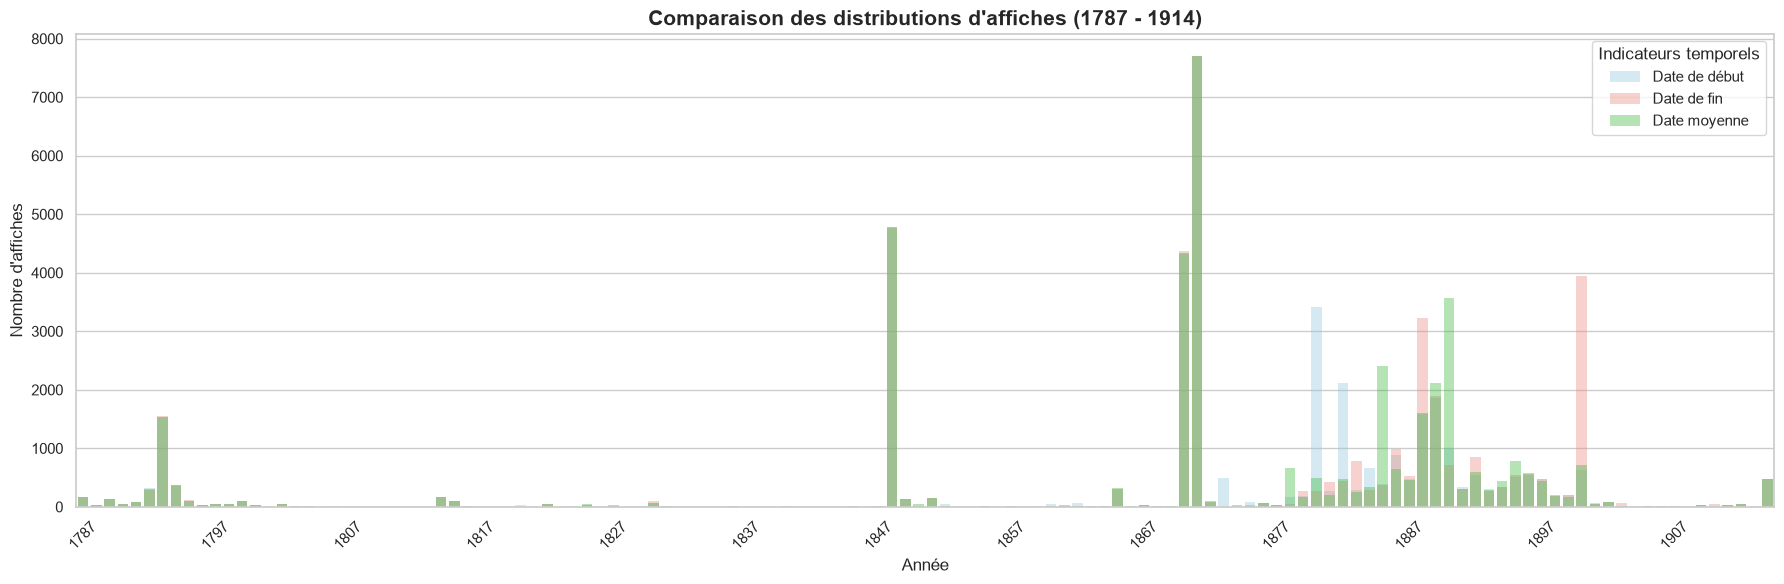

In [ ]:
# 1. Configuration du style et de la taille de la figure
plt.figure(figsize=(18, 6))
sns.set_theme(style="whitegrid")

# 2. Définition stricte des bornes d'années
annee_min = 1787
annee_max = 1914
toutes_les_annees = range(annee_min, annee_max + 1)

# 3. Filtrage du DataFrame sur la période 1787-1914 et comptage
df_filtre = df[(df['debut'] >= annee_min) & (df['fin'] <= annee_max)]

count_debut = df_filtre['debut'].value_counts().reindex(toutes_les_annees, fill_value=0)
count_fin   = df_filtre['fin'].value_counts().reindex(toutes_les_annees, fill_value=0)
count_moy   = df_filtre['moy'].round().value_counts().reindex(toutes_les_annees, fill_value=0)

# Création du DataFrame structuré pour le barplot
df_counts = pd.DataFrame({
    'Annee': toutes_les_annees,
    'Debut': count_debut.values,
    'Fin': count_fin.values,
    'Moyenne': count_moy.values
})

# 4. Superposition des 3 séries avec sns.barplot
sns.barplot(data=df_counts, x='Annee', y='Debut', color='skyblue', label='Date de début', alpha=0.4, edgecolor='none')
sns.barplot(data=df_counts, x='Annee', y='Fin', color='salmon', label='Date de fin', alpha=0.4, edgecolor='none')
sns.barplot(data=df_counts, x='Annee', y='Moyenne', color='limegreen', label='Date moyenne', alpha=0.4, edgecolor='none')

# 5. Ajustement dynamique des étiquettes (axe X calibré de 1787 à 1914)
pas_affichage = 10
plt.xticks(
    ticks=range(0, len(toutes_les_annees), pas_affichage), 
    labels=range(annee_min, annee_max + 1, pas_affichage), 
    rotation=45
)

# 6. Personnalisation des axes, du titre et de la légende
plt.title("Comparaison des distributions d'affiches (1787 - 1914)", fontsize=15, fontweight='bold')
plt.xlabel("Année", fontsize=12)
plt.ylabel("Nombre d'affiches", fontsize=12)

# Affichage de la légende
plt.legend(title="Indicateurs temporels", fontsize=11, title_fontsize=12)

# 7. Affichage du graphique
plt.tight_layout()
plt.savefig(" ", dpi=600)
plt.show()
plt.close()

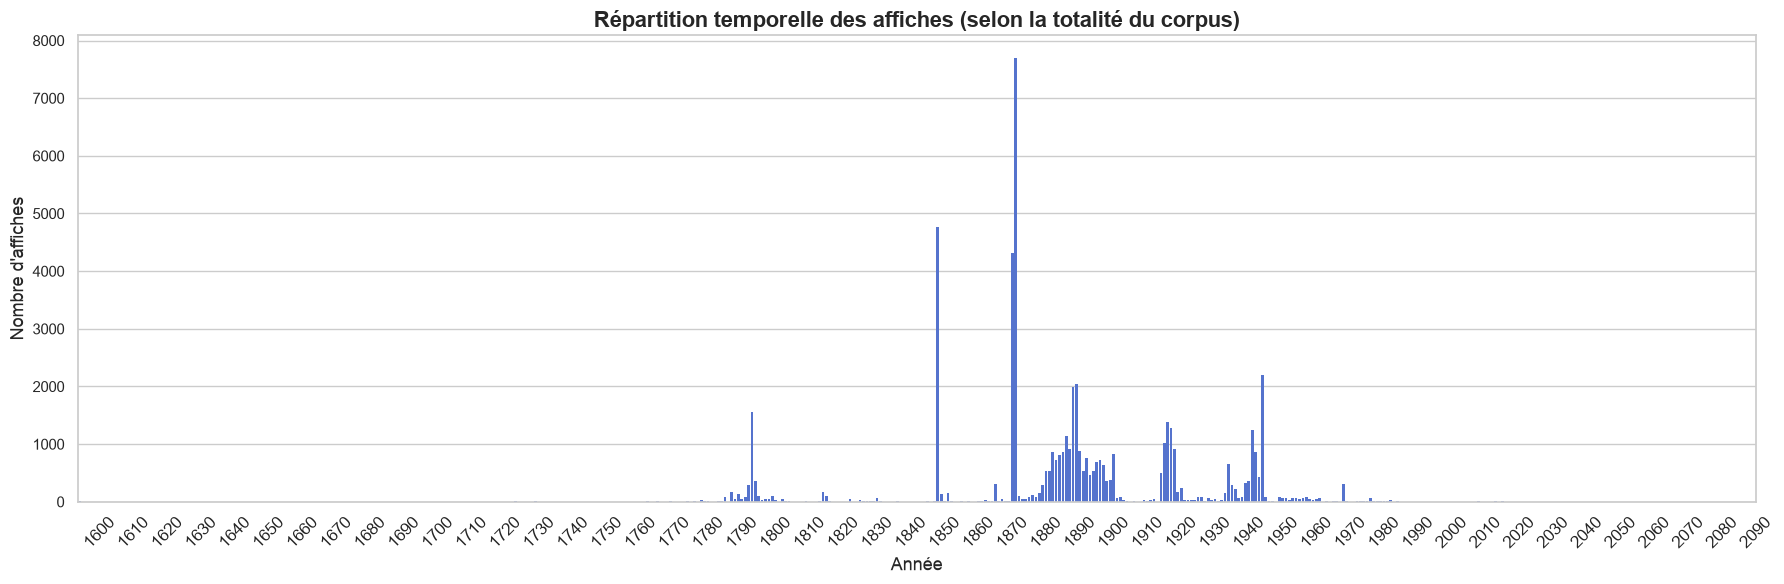

In [ ]:
# TOUTES LES ANNÉES

# 1. On trouve automatiquement la borne minimale et maximale de ton jeu de données
annee_min = int(df['debut'].min())
annee_max = int(df['fin'].max())

# On initialise le dictionnaire de manière dynamique sur toute la plage (+1 pour inclure l'année max)
cumul_probabiliste = {annee: 0.0 for annee in range(annee_min, annee_max + 1)}

# 2. Parcours de ton DataFrame complet
for idx, row in df.iterrows():
    debut = row['debut']
    fin = row['fin']
    
    if pd.notna(debut) and pd.notna(fin) and fin >= debut:
        largeur_intervalle = int(fin) - int(debut) + 1
        probabilite_par_annee = 1.0 / largeur_intervalle
        
        for annee in range(int(debut), int(fin) + 1):
            if annee in cumul_probabiliste:
                cumul_probabiliste[annee] += probabilite_par_annee

# 3. Conversion du résultat en DataFrame pour le graphique
df_cumul = pd.DataFrame(list(cumul_probabiliste.items()), columns=['Annee', 'Poids_Probabiliste'])

# 4. Génération de l'histogramme complet
plt.figure(figsize=(18, 6))
sns.set_theme(style="whitegrid")

sns.barplot(data=df_cumul, x='Annee', y='Poids_Probabiliste', color='royalblue', edgecolor='none')

# Ajustement dynamique des étiquettes de l'axe X (on affiche une année tous les 10 ans pour éviter les chevauchements)
pas_affichage = 10
plt.xticks(
    ticks=range(6, 506, pas_affichage), 
    labels=range(1600, 2100, pas_affichage), 
    rotation=45,
    fontsize= 12
)

plt.title("Répartition temporelle des affiches (selon la totalité du corpus)", fontsize=16, fontweight='bold')
plt.xlabel("Année", fontsize=13)
plt.ylabel("Nombre d'affiches", fontsize=13)

plt.tight_layout()
plt.savefig(f" ", dpi = 600)
plt.show()
plt.close()

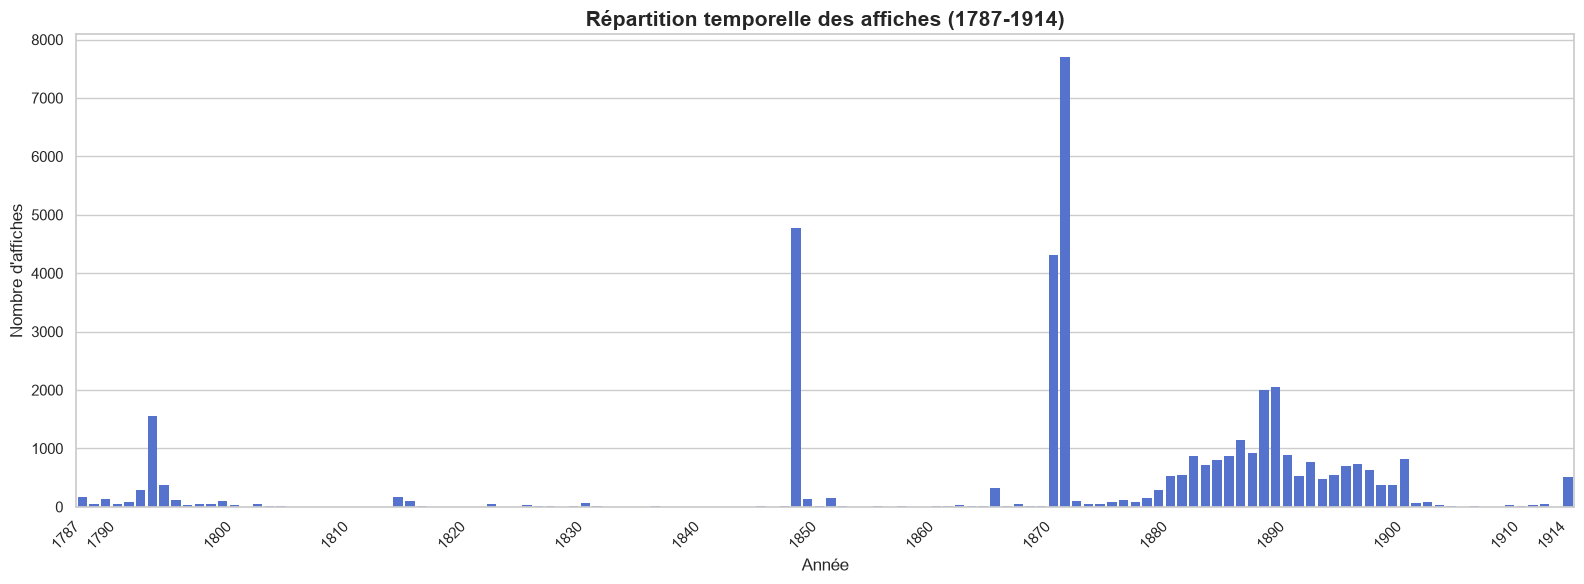

In [ ]:
# PÉRIODE 1787 À 1914

# 1. Définition stricte des bornes temporelles demandées
annee_min = 1787
annee_max = 1914

# On initialise le dictionnaire dynamiquement sur cette plage spécifique
cumul_probabiliste = {annee: 0.0 for annee in range(annee_min, annee_max + 1)}

# 2. Parcours du DataFrame complet
for idx, row in df.iterrows():
    debut = row['debut']
    fin = row['fin']
    
    if pd.notna(debut) and pd.notna(fin) and fin >= debut:
        largeur_intervalle = int(fin) - int(debut) + 1
        probabilite_par_annee = 1.0 / largeur_intervalle
        
        # On ne retient l'impact que pour les années comprises dans notre borne 1787-1914
        for annee in range(int(debut), int(fin) + 1):
            if annee in cumul_probabiliste:
                cumul_probabiliste[annee] += probabilite_par_annee

# 3. Conversion du résultat en DataFrame pour le graphique
df_cumul = pd.DataFrame(list(cumul_probabiliste.items()), columns=['Annee', 'Poids_Probabiliste'])

# 4. Génération de l'histogramme ciblé
plt.figure(figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Tracé des barres
sns.barplot(data=df_cumul, x='Annee', y='Poids_Probabiliste', color='royalblue', edgecolor='none')

# Ajustement dynamique et propre de l'axe X
pas_affichage = 10  # Une étiquette tous les 10 ans

# On génère les positions des étiquettes par rapport aux index du DataFrame
indices_affichage = [i for i, annee in enumerate(df_cumul['Annee']) if annee % pas_affichage == 0]
annees_affichage = [annee for annee in df_cumul['Annee'] if annee % pas_affichage == 0]

# Si l'année 1787 ou 1914 n'est pas incluse dans les multiples de 10, on peut forcer leur affichage pour la clarté :
if annee_min not in annees_affichage:
    indices_affichage.insert(0, 0)
    annees_affichage.insert(0, annee_min)
if annee_max not in annees_affichage:
    indices_affichage.append(len(df_cumul) - 1)
    annees_affichage.append(annee_max)

plt.xticks(
    ticks=indices_affichage, 
    labels=annees_affichage, 
    rotation=45,
    ha='right'
)

plt.title("Répartition temporelle des affiches (1787-1914)", fontsize=15, fontweight='bold')
plt.xlabel("Année", fontsize=12) # Remonté la taille de la police à 12 (4 était trop petit/illisible)
plt.ylabel("Nombre d'affiches", fontsize=12)

plt.tight_layout()
plt.savefig(" ", dpi=600)
plt.show()
plt.close()

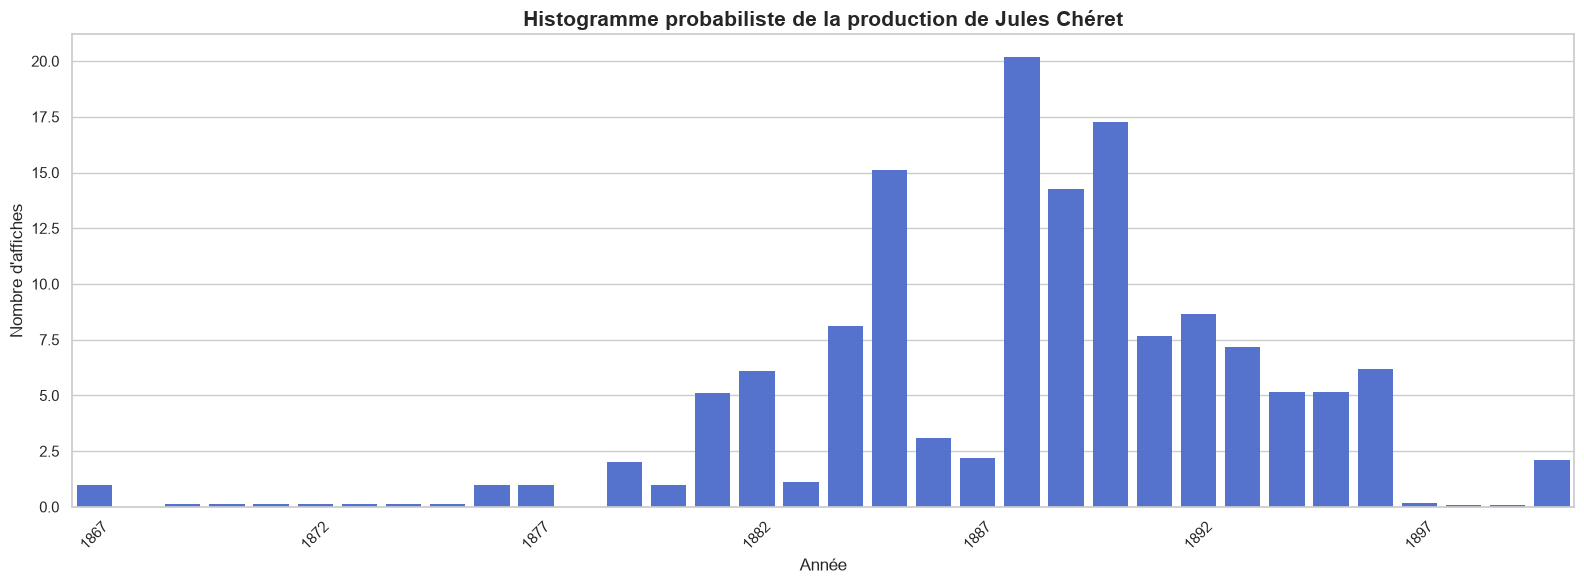

In [ ]:
# PRODUCTION DE JULES CHERET
df_cheret = df[df['nomagent'] == 'Chéret, Jules'].copy()

# 1. On trouve automatiquement la borne minimale et maximale du sous-ensemble
annee_min = int(df_cheret['debut'].min())
annee_max = int(df_cheret['fin'].max())

# On initialise le dictionnaire de manière dynamique sur toute la plage
cumul_probabiliste = {annee: 0.0 for annee in range(annee_min, annee_max + 1)}

# 2. Parcours du DataFrame filtré pour Chéret
for idx, row in df_cheret.iterrows():
    debut = row['debut']
    fin = row['fin']
    
    if pd.notna(debut) and pd.notna(fin) and fin >= debut:
        largeur_intervalle = int(fin) - int(debut) + 1
        probabilite_par_annee = 1.0 / largeur_intervalle
        
        for annee in range(int(debut), int(fin) + 1):
            if annee in cumul_probabiliste:
                cumul_probabiliste[annee] += probabilite_par_annee

# 3. Conversion du résultat en DataFrame pour le graphique
df_cheret_cumul = pd.DataFrame(list(cumul_probabiliste.items()), columns=['Annee', 'Poids_Probabiliste'])

# 4. Génération de l'histogramme complet
plt.figure(figsize=(16, 6))
sns.set_theme(style="whitegrid")

sns.barplot(data=df_cheret_cumul, x='Annee', y='Poids_Probabiliste', color='royalblue', edgecolor='none')


pas_affichage = 5  
plt.xticks(
    ticks=range(0, len(df_cheret_cumul), pas_affichage), 
    labels=range(annee_min, annee_max + 1, pas_affichage), 
    rotation=45
)

plt.title("Histogramme probabiliste de la production de Jules Chéret", fontsize=15, fontweight='bold')
plt.xlabel("Année", fontsize=12) # J'ai remis la taille à 12, 4 était minuscule !
plt.ylabel("Nombre d'affiches", fontsize=12)

plt.tight_layout()
plt.savefig(" ", dpi=600)
plt.show()
plt.close()

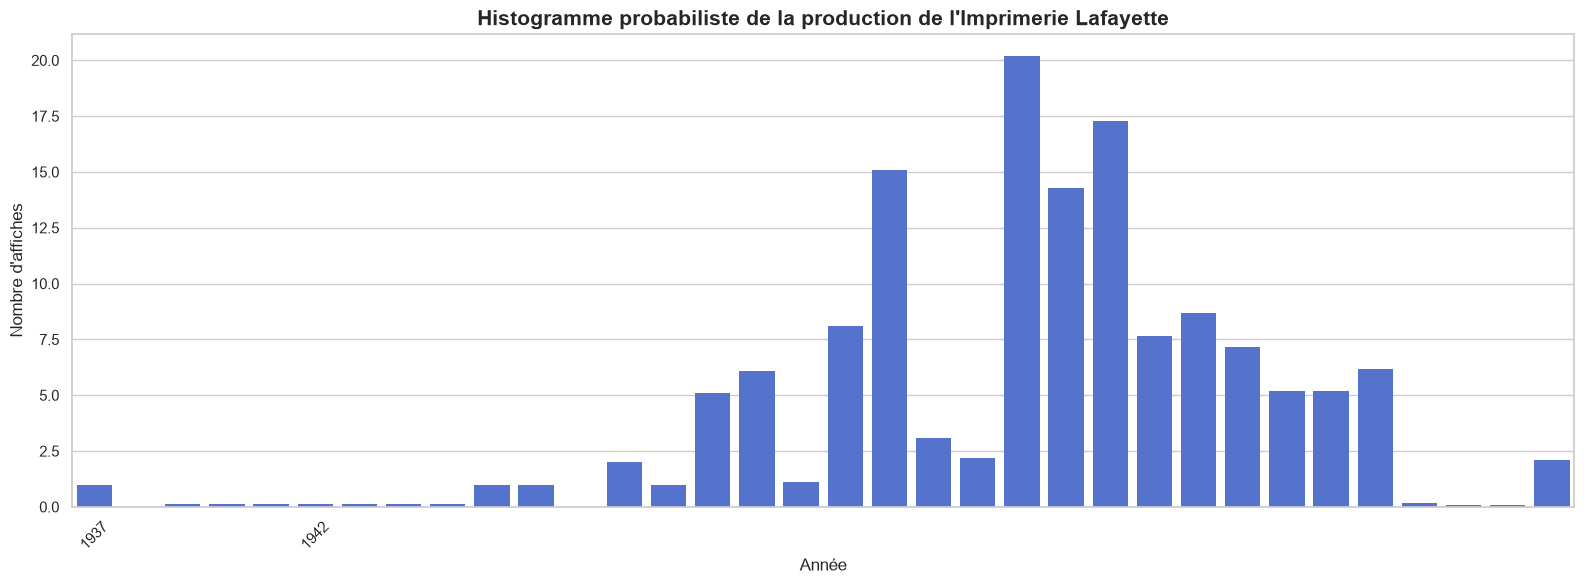

In [ ]:

# PRODUCTION IMPRIMERIE LAFAYETTE
df_lafayette = df[df['nomagent'] == 'Imprimerie Lafayette'].copy()

# 1. On trouve automatiquement la borne minimale et maximale du sous-ensemble
annee_min = int(df_lafayette['debut'].min())
annee_max = int(df_lafayette['fin'].max())

# On initialise le dictionnaire de manière dynamique sur toute la plage
cumul_probabiliste = {annee: 0.0 for annee in range(annee_min, annee_max + 1)}

# 2. Parcours du DataFrame filtré pour Chéret
for idx, row in df_lafayette.iterrows():
    debut = row['debut']
    fin = row['fin']
    
    if pd.notna(debut) and pd.notna(fin) and fin >= debut:
        largeur_intervalle = int(fin) - int(debut) + 1
        probabilite_par_annee = 1.0 / largeur_intervalle
        
        for annee in range(int(debut), int(fin) + 1):
            if annee in cumul_probabiliste:
                cumul_probabiliste[annee] += probabilite_par_annee

# 3. Conversion du résultat en DataFrame pour le graphique
df_lafayette_cumul = pd.DataFrame(list(cumul_probabiliste.items()), columns=['Annee', 'Poids_Probabiliste'])

# 4. Génération de l'histogramme complet
plt.figure(figsize=(16, 6))
sns.set_theme(style="whitegrid")

sns.barplot(data=df_cheret_cumul, x='Annee', y='Poids_Probabiliste', color='royalblue', edgecolor='none')

pas_affichage = 5  
plt.xticks(
    ticks=range(0, len(df_lafayette_cumul), pas_affichage), 
    labels=range(annee_min, annee_max + 1, pas_affichage), 
    rotation=45
)

plt.title("Histogramme probabiliste de la production de l'Imprimerie Lafayette", fontsize=15, fontweight='bold')
plt.xlabel("Année", fontsize=12) # J'ai remis la taille à 12, 4 était minuscule !
plt.ylabel("Nombre d'affiches", fontsize=12)

plt.tight_layout()
plt.savefig(" ", dpi=600)
plt.show()
plt.close()

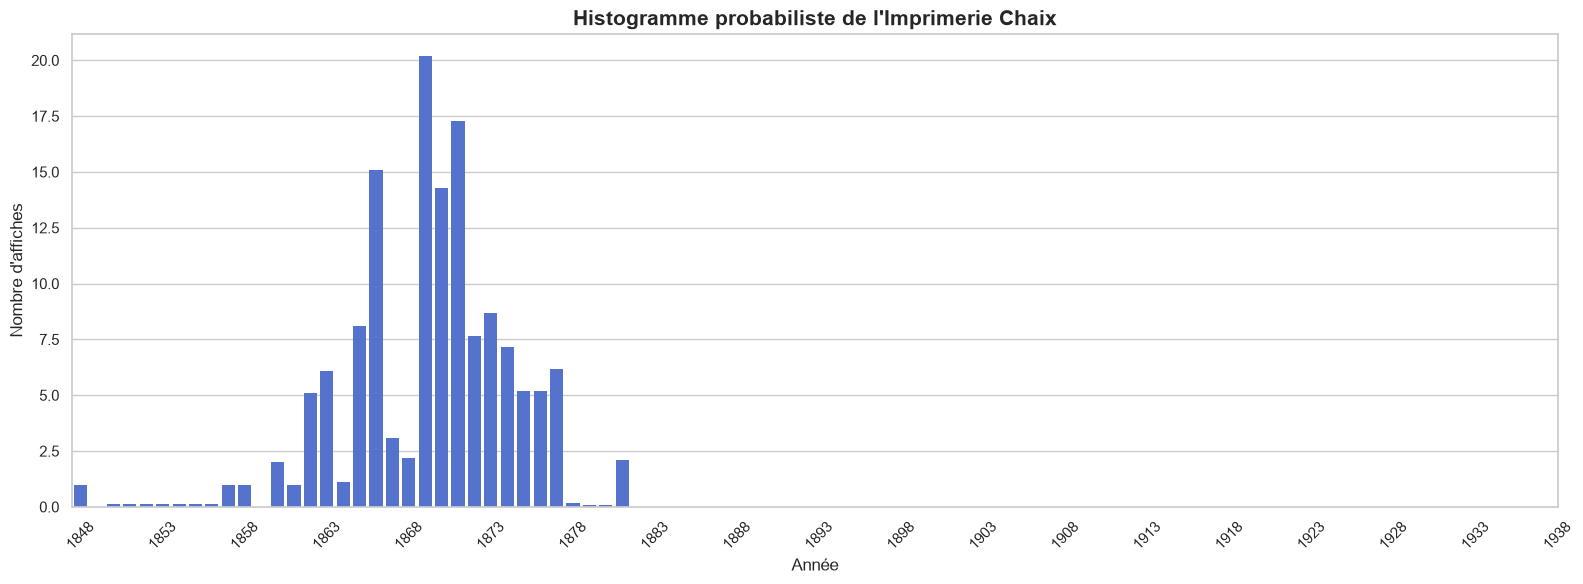

In [ ]:
# IMPRIMERIE CHAIX

# CORRECTION : On applique le filtre pour obtenir un vrai DataFrame filtré
df_chaix = df[df['nomagent'] == 'Imprimerie Chaix'].copy()

# 1. On trouve automatiquement la borne minimale et maximale du sous-ensemble
annee_min = int(df_chaix['debut'].min())
annee_max = int(df_chaix['fin'].max())

# On initialise le dictionnaire de manière dynamique sur toute la plage
cumul_probabiliste = {annee: 0.0 for annee in range(annee_min, annee_max + 1)}

# 2. Parcours du DataFrame filtré pour Chéret
for idx, row in df_chaix.iterrows():
    debut = row['debut']
    fin = row['fin']
    
    if pd.notna(debut) and pd.notna(fin) and fin >= debut:
        largeur_intervalle = int(fin) - int(debut) + 1
        probabilite_par_annee = 1.0 / largeur_intervalle
        
        for annee in range(int(debut), int(fin) + 1):
            if annee in cumul_probabiliste:
                cumul_probabiliste[annee] += probabilite_par_annee

# 3. Conversion du résultat en DataFrame pour le graphique
df_chaix_cumul = pd.DataFrame(list(cumul_probabiliste.items()), columns=['Annee', 'Poids_Probabiliste'])

# 4. Génération de l'histogramme complet
plt.figure(figsize=(16, 6))
sns.set_theme(style="whitegrid")

sns.barplot(data=df_cheret_cumul, x='Annee', y='Poids_Probabiliste', color='royalblue', edgecolor='none')

pas_affichage = 5  
plt.xticks(
    ticks=range(0, len(df_chaix_cumul), pas_affichage), 
    labels=range(annee_min, annee_max + 1, pas_affichage), 
    rotation=45
)

plt.title("Histogramme probabiliste de l'Imprimerie Chaix", fontsize=15, fontweight='bold')
plt.xlabel("Année", fontsize=12) # J'ai remis la taille à 12, 4 était minuscule !
plt.ylabel("Nombre d'affiches", fontsize=12)

plt.tight_layout()
plt.savefig(" ", dpi=600)
plt.show()
plt.close()

In [43]:
#On ajoute les reponses de la requete a un df en passant par un format csv
endpoint.setQuery(query_date_intervalle)
endpoint.setReturnFormat(CSV)
resultats_csv = endpoint.queryAndConvert()
#bytesIO permet de lire les bytes comme du csv
df = pd.read_csv(io.BytesIO(resultats_csv))
